**Classification Hands-On(Training and Evaluation Demo)**

Goal:
- Training Logistic Regression
- Evaluating with metrics + ROC AUC

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

**1. Load Data**

In [3]:
df = pd.read_csv("diabetes.csv")

In [4]:
df.shape

(768, 9)

In [5]:
df.columns.to_list()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**2. Quick Checks(high-level)**

In [ ]:
#Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

**3.Split Features and Target**

In [11]:
X= df.drop(columns=["Outcome"])
y = df["Outcome"]

In [12]:
X[:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [13]:
y[:5]

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

**4. Train Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,random_state=42,
    stratify=y
)

In [17]:
print("X Shape:",X.shape)
print("X_train Shape:",X_train.shape)
print("X_test Shape:",X_test.shape)

X Shape: (768, 8)
X_train Shape: (614, 8)
X_test Shape: (154, 8)


**5. Scale the features**

- Fit scaler only on training data, then transform both training and test data

In [18]:
scaler = StandardScaler()

In [19]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**6. Model Training(Logistic Regression)**

In [20]:
model = LogisticRegression()

In [21]:
#Training the Model
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

**7. Predictions**

In [32]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_test_prob = model.predict_proba(X_test_scaled)[:, 1]


In [25]:
X_train_scaled[:3].tolist()

[[-0.8513550738681201,
  -0.9801306786815437,
  -0.40478372420423153,
  -0.5539725609683268,
  -0.3313192794050237,
  -0.6076784605515674,
  0.31079384041548314,
  -0.7921692833892792],
 [0.3565756375241982,
  0.16144422497410207,
  0.465368421656243,
  0.3927870023121129,
  -0.5263980861381337,
  -0.3021390244014409,
  -0.11643850592424994,
  0.5610338186827566],
 [-0.5493723960200406,
  -0.5044744688250247,
  -0.6223217606693501,
  1.2133119571551605,
  0.14244353694681483,
  0.37259389709675395,
  -0.7648620670356181,
  -0.707594089509777]]

In [26]:
y_train[:3]

353    0
711    0
373    0
Name: Outcome, dtype: int64

In [27]:
y_train_pred[:3]

array([0, 0, 0])

In [28]:
y_test_pred[:3]

array([1, 0, 0])

In [33]:
y_test_prob[:3]

array([0.61667353, 0.11278116, 0.27253958])

**8. Evaluation Metric(Train and Test)**

In [37]:
def print_metrics(title, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(title)
    print(f"  Accuracy: {acc:.2%} ")
    print(f"  Precision: {prec:.2%} ")
    print(f"  Recall: {rec:.2%} ")
    print(f"  F1-Score: {f1:.2%} ")

In [38]:
print_metrics("TRAIN METRICS", y_train, y_train_pred)
print_metrics("TEST METRICS", y_test, y_test_pred)

TRAIN METRICS
  Accuracy: 79.15% 
  Precision: 75.90% 
  Recall: 58.88% 
  F1-Score: 66.32% 
TEST METRICS
  Accuracy: 71.43% 
  Precision: 60.87% 
  Recall: 51.85% 
  F1-Score: 56.00% 


Confusion Matrix:
[[82 18]
 [26 28]]


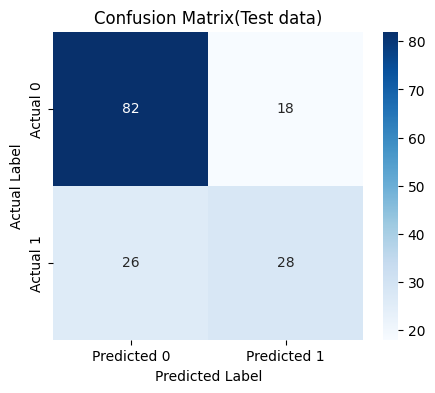

In [41]:
cm = confusion_matrix(y_test,y_test_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0","Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix(Test data)")
plt.show()

**9. ROC Curve + AUC**

ROC-AUC Score:0.823


Text(0, 0.5, 'True Positive Rate')

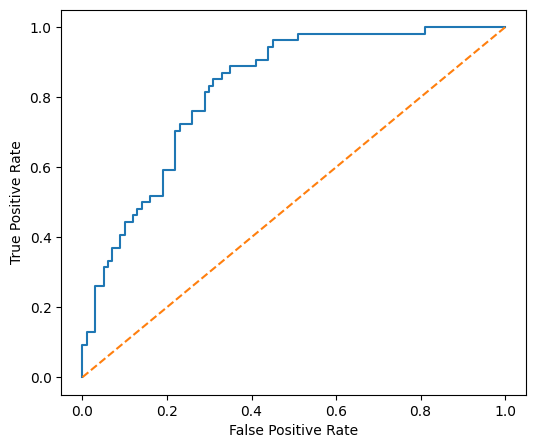

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)
print(f"ROC-AUC Score:{auc_score:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label = f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")